In [1]:
import mesa
import matplotlib.pyplot as plt
import numpy as np
from collections import deque

# === SCALE CONSTANTS (1m cells) ===
CELL_SIZE_M = 1.0
SECONDS_PER_STEP = 1.0

# === GRID DIMENSIONS (cells) ===
WIDTH = 58    # cols, west -> east
HEIGHT = 67   # rows, north -> south

walkable = set()
exits = set()
spawn400 = set()
spawn401 = set()
dead = set()

def fill(r0, r1, c0, c1, target_set, also_walkable=True):
    """Add rows r0..r1, cols c0..c1 (inclusive) to target_set.
    Cells stored as (col, row) = (x, y) for Mesa."""
    for r in range(r0, r1 + 1):
        for c in range(c0, c1 + 1):
            if 0 <= r < HEIGHT and 0 <= c < WIDTH:
                target_set.add((c, r))
                if also_walkable:
                    walkable.add((c, r))

# Assembly rooms (spawn zones, walkable)
fill(44, 66, 42, 57, spawn400)        # RCF 400 (east, large)
fill(59, 66, 18, 32, spawn401)        # RCF 401 (lower-west)

# Circulation open area
fill(44, 58, 22, 41, walkable)

# North corridor to Stair 2
fill(20, 43, 30, 34, walkable)
fill(20, 24, 30, 44, walkable)
fill(8, 19, 30, 34, walkable)
fill(8, 12, 18, 31, walkable)

# West nook to Stair 3 / bathrooms
fill(46, 54, 18, 21, walkable)

# Exits (stair entries, walkable)
fill(8, 12, 15, 17, exits)            # Stair 2
fill(55, 58, 18, 25, exits)           # Stair 3

# Non-walkable obstacles
fill(14, 19, 40, 44, dead, also_walkable=False)   # elevators
fill(46, 49, 14, 21, dead, also_walkable=False)   # bathrooms
fill(59, 66, 33, 41, dead, also_walkable=False)   # deadspace between rooms

print(f"Walkable cells: {len(walkable)}")
print(f"Exit cells:     {len(exits)}")
print(f"RCF 400 spawn:  {len(spawn400)} cells")
print(f"RCF 401 spawn:  {len(spawn401)} cells")
print(f"Deadspace:      {len(dead)} cells")

Walkable cells: 1145
Exit cells:     47
RCF 400 spawn:  368 cells
RCF 401 spawn:  120 cells
Deadspace:      134 cells


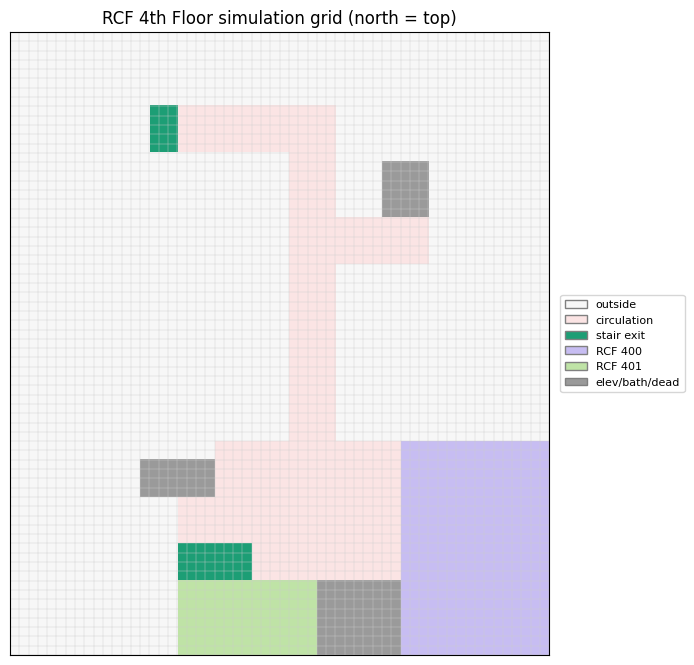

In [2]:
def render_floor(occupant_positions=None):
    arr = np.zeros((HEIGHT, WIDTH), dtype=int)
    for (c, r) in walkable:   arr[r][c] = 1
    for (c, r) in spawn400:   arr[r][c] = 3
    for (c, r) in spawn401:   arr[r][c] = 4
    for (c, r) in exits:      arr[r][c] = 2
    for (c, r) in dead:       arr[r][c] = 5

    from matplotlib.colors import ListedColormap
    from matplotlib.patches import Patch
    colors = ['#f7f7f7', '#fbe4e4', '#1d9e75', '#c7bdf2', '#bfe3a6', '#9a9a9a']
    labels = ['outside', 'circulation', 'stair exit', 'RCF 400', 'RCF 401', 'elev/bath/dead']
    cmap = ListedColormap(colors)

    fig, ax = plt.subplots(figsize=(7, 8))
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=5, origin='upper', interpolation='nearest')
    for x in range(WIDTH + 1):  ax.axvline(x - 0.5, color='#cccccc', linewidth=0.3)
    for y in range(HEIGHT + 1): ax.axhline(y - 0.5, color='#cccccc', linewidth=0.3)
    if occupant_positions:
        xs = [p[0] for p in occupant_positions]
        ys = [p[1] for p in occupant_positions]
        ax.scatter(xs, ys, s=8, c='#333333', alpha=0.7, zorder=5)
    ax.set_title('RCF 4th Floor simulation grid (north = top)')
    ax.set_xticks([]); ax.set_yticks([])
    legend = [Patch(facecolor=colors[i], edgecolor='gray', label=labels[i]) for i in range(len(labels))]
    ax.legend(handles=legend, loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

render_floor()

In [3]:
def compute_distance_field(walkable, exits):
    """BFS from all exits. Returns {cell: steps-to-nearest-exit}, routing
    only through walkable cells."""
    distance = {}
    queue = deque()
    for cell in exits:
        distance[cell] = 0
        queue.append(cell)
    directions = [(-1,-1),(0,-1),(1,-1),(-1,0),(1,0),(-1,1),(0,1),(1,1)]
    while queue:
        cx, cy = queue.popleft()
        current = distance[(cx, cy)]
        for dx, dy in directions:
            nb = (cx + dx, cy + dy)
            if nb in walkable and nb not in distance:
                distance[nb] = current + 1
                queue.append(nb)
    return distance

distance_field = compute_distance_field(walkable, exits)
print(f"Cells with a path to an exit: {len(distance_field)} / {len(walkable)} walkable")
unreachable = walkable - set(distance_field.keys())
print(f"Unreachable walkable cells: {len(unreachable)}")
print(f"Max distance to an exit: {max(distance_field.values())} steps")

Cells with a path to an exit: 1145 / 1145 walkable
Unreachable walkable cells: 0
Max distance to an exit: 32 steps


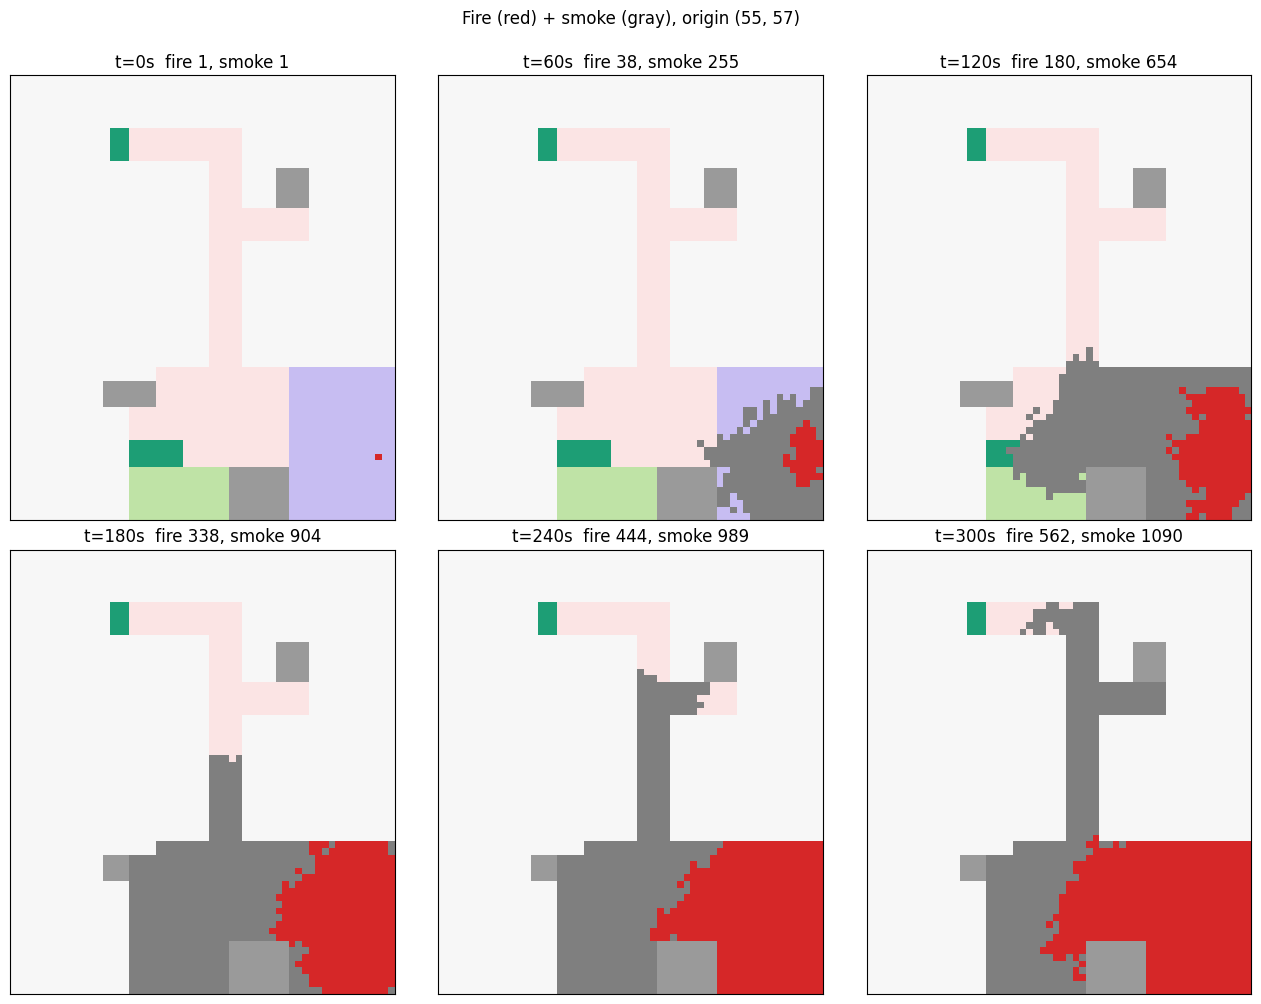

Origin: (55, 57) (RCF 400)
At t=300s: fire 562 cells (49% of floor), smoke 1090 cells (95%)
Measured fire front speed:  0.045 m/s (target ~0.05)
Measured smoke front speed: 0.062 m/s (target ~0.15)


In [4]:
import random

# ============================================================
# V3 CELL 4: FIRE + SMOKE SPREAD MECHANICS (no occupants yet).
#
# Fire:  set of burning cells. Each step, every walkable non-burning
#        cell with a burning 8-dir neighbor ignites with prob FIRE_SPREAD_P.
#        Fire BLOCKS movement and KILLS occupants standing in it.
# Smoke: set of smoky cells. Spreads the same way but FASTER
#        (SMOKE_SPREAD_P). Smoke does NOT block movement or kill in v3;
#        it HALVES walking speed. Burning cells are always also smoky.
#
# CALIBRATED SPREAD PROBABILITIES.
# These are per-neighbor probabilities, and they COMPOUND: a cell on a
# fire front has ~3 burning neighbors, so its real per-step ignition
# chance is 1-(1-p)^3, not p. The first version used p=0.05 and produced
# an emergent front speed ~3x the intent (fire consumed 99% of the floor
# in 5 min). Calibrated so the EMERGENT front speed hits the stated
# targets, verified by the measurement printout at the bottom:
#   fire target:  ~0.05 m/s front (~3 m/min) -> p = 0.017
#   smoke target: ~0.15 m/s front (3x fire)  -> p = 0.053
#
# CONSERVATIVE ASSUMPTIONS (stated, tunable):
#   No sprinkler suppression, even though RCF is sprinklered:
#   the conservative design question is "what if the system fails?"
#   Smoke spreads 3x faster than flame and impairs movement.
# ============================================================

FIRE_SPREAD_P  = 0.017
SMOKE_SPREAD_P = 0.053

# 8-directional -- matches the BFS directions. Diagonal ignition is
# physical: a diagonal cell is ~1.4 m away, within radiant ignition range.
SPREAD_DIRS = [(-1,-1),(0,-1),(1,-1),(-1,0),(1,0),(-1,1),(0,1),(1,1)]

def spread_step(region, p, rng):
    """One step of probabilistic cellular spread. Works for fire AND
    smoke -- only the probability differs. Takes the current set of
    cells, returns the (same or larger) new set. Spreads only through
    walkable cells: nothing burns through walls."""
    newly = set()
    for (cx, cy) in region:
        for dx, dy in SPREAD_DIRS:
            nb = (cx + dx, cy + dy)
            if nb in walkable and nb not in region and nb not in newly:
                if rng.random() < p:
                    newly.add(nb)
    return region | newly

# ---- Isolation test: one fire+smoke sequence, snapshotted ----
rng = random.Random(0)
# Origin: random cell in the assembly rooms (highest occupant density,
# highest ignition likelihood). sorted() makes the seeded choice
# reproducible -- sets have no stable order.
origin = rng.choice(sorted(spawn400 | spawn401))
burning = {origin}
smoky   = {origin}

snapshot_times = [0, 60, 120, 180, 240, 300]
snaps = {0: (set(burning), set(smoky))}
for t in range(1, max(snapshot_times) + 1):
    burning = spread_step(burning, FIRE_SPREAD_P, rng)
    smoky   = spread_step(smoky | burning, SMOKE_SPREAD_P, rng)  # smoke includes fire
    if t in snapshot_times:
        snaps[t] = (set(burning), set(smoky))

from matplotlib.colors import ListedColormap
fig, axes = plt.subplots(2, 3, figsize=(13, 10))
# Categories: 0 outside, 1 walkable, 2 exit, 3 RCF400, 4 RCF401,
#             5 dead, 6 SMOKE (gray), 7 FIRE (red). Fire stamped last = wins.
colors = ['#f7f7f7', '#fbe4e4', '#1d9e75', '#c7bdf2', '#bfe3a6',
          '#9a9a9a', '#7f7f7f', '#d62728']
cmap = ListedColormap(colors)
for ax, t in zip(axes.flat, snapshot_times):
    b, s = snaps[t]
    arr = np.zeros((HEIGHT, WIDTH), dtype=int)
    for (c, r) in walkable: arr[r][c] = 1
    for (c, r) in spawn400: arr[r][c] = 3
    for (c, r) in spawn401: arr[r][c] = 4
    for (c, r) in exits:    arr[r][c] = 2
    for (c, r) in dead:     arr[r][c] = 5
    for (c, r) in s:        arr[r][c] = 6
    for (c, r) in b:        arr[r][c] = 7
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=7, origin='upper',
              interpolation='nearest')
    ax.set_title(f"t={t}s  fire {len(b)}, smoke {len(s)}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Fire (red) + smoke (gray), origin {origin}", y=1.0)
plt.tight_layout(); plt.show()

print(f"Origin: {origin} ({'RCF 400' if origin in spawn400 else 'RCF 401'})")
b300, s300 = snaps[300]
print(f"At t=300s: fire {len(b300)} cells ({len(b300)/len(walkable)*100:.0f}% of floor), "
      f"smoke {len(s300)} cells ({len(s300)/len(walkable)*100:.0f}%)")

# MEASURED front speed: treat the burning blob as a disk, radius =
# sqrt(area/pi); speed = radius / elapsed time. This verifies the
# calibration empirically instead of trusting the algebra.
# (Caveat: if smoke saturates the floor before t=300 its measured speed
# reads low -- the fire number is the meaningful one in that case.)
import math
r_fire = math.sqrt(len(b300) / math.pi)          # cells == meters
print(f"Measured fire front speed:  {r_fire/300:.3f} m/s (target ~0.05)")
r_smoke = math.sqrt(len(s300) / math.pi)
print(f"Measured smoke front speed: {r_smoke/300:.3f} m/s (target ~0.15)")

In [5]:
# ============================================================
# V3 CELL 5: OccupantAgent -- fire awareness, smoke effects, standoff.
# Rules:
#   - SMOKE CUE ENDS PRE-MOVEMENT: the Weibull delay models alarm
#     response; smoke at your cell is a direct cue that ends it
#     immediately (Gwynne/Boyce: cue intensity shortens pre-movement).
#   - smoke HALVES walking speed (conservative: smoke impairs)
#   - FLAME STANDOFF: radiant heat keeps people back from fire, so
#     agents avoid the model's fire_halo (burning cells + 1 m fringe)
#     whenever a safe downhill move exists. If the ONLY downhill move
#     is through the halo, they take it (desperation) -- but they
#     NEVER step into an actually burning cell.
#   - terminal state "casualty" is set by the model
# ============================================================

class OccupantAgent(mesa.Agent):
    def __init__(self, model):
        super().__init__(model)
        self.state = "moving"                  # moving | escaped | casualty
        weibull_shape = 1.8
        weibull_scale = 35.0
        self.reaction_delay = int(self.random.weibullvariate(weibull_scale, weibull_shape))
        self.steps_waited = 0
        self.target_stair = "stair3"           # model reassigns half to stair2
        self._smoke_skip = False               # toggles to halve speed in smoke

    def step(self):
        if self.state != "moving":
            return

        # SMOKE CUE: smoke at my cell ends pre-movement permanently.
        if self.pos in self.model.smoky:
            self.steps_waited = self.reaction_delay

        # Pre-movement delay (alarm response), for agents not yet cued.
        if self.steps_waited < self.reaction_delay:
            self.steps_waited += 1
            return

        # SMOKE SLOWDOWN: in smoke, act only every other step.
        if self.pos in self.model.smoky:
            self._smoke_skip = not self._smoke_skip
            if self._smoke_skip:
                return

        my_field = self.model.dist_to[self.target_stair]

        # Escape logic (door budget throttle), unchanged.
        if self.pos in self.model.exits and self.model.cell_to_door.get(self.pos) == self.target_stair:
            door = self.target_stair
            if self.model.door_budget[door] >= 1.0:
                self.model.door_budget[door] -= 1.0
                self.state = "escaped"
                self.model.escaped_count += 1
                self.model.door_escape_count[door] += 1
                self.model.grid.remove_agent(self)
            return

        # MOVEMENT with standoff. Never into flame; prefer staying out
        # of the 1 m halo; fall back through the halo only if it's the
        # sole downhill option (desperation).
        neighbors = self.model.grid.get_neighborhood(self.pos, moore=True, include_center=False)
        candidates = [c for c in neighbors
                      if c in my_field and c not in self.model.burning]
        if not candidates:
            return
        my_dist = my_field.get(self.pos, float("inf"))
        safe = [c for c in candidates if c not in self.model.fire_halo]
        # Try safe-and-downhill first, then any-non-flame-and-downhill.
        for pool in (safe, candidates):
            if pool:
                best = min(pool, key=lambda c: my_field[c])
                if my_field[best] < my_dist:
                    self.model.grid.move_agent(self, best)
                    return

In [6]:
# ============================================================
# V3 CELL 6: RCFFireModel -- v2's floor + a spreading hazard.
# Per-step sequence (NOTE THE ORDER):
#   1) door budgets top up
#   2) fire KILLS anyone in cells already burning (so a cell that
#      ignites becomes lethal one second AFTER ignition -- a 1 m cell
#      is not instantly untenable; occupants get exactly one move
#      opportunity to get off it, which smoke-slowed agents may miss)
#   3) fire spreads, smoke spreads; fire_halo (burning + 1 m fringe)
#      is recomputed for the agents' radiant-heat standoff
#   4) every REROUTE_INTERVAL steps: distance fields recomputed on the
#      fire-free floor; agents whose stair is unreachable switch
#   5) collect data, agents act
#
# T=0 RULE: no agent spawns on the origin cell (the person at the
# ignition point fled during the unmodeled incipient phase), so there
# are NO t=0 deaths -- casualties come only from spread catching people.
#
# CONSERVATIVE: REROUTE_INTERVAL = 10 s; 1 m standoff is far less than
# real radiant standoff; a burnt stair entry is a lost door; no
# sprinkler suppression.
# ============================================================

REROUTE_INTERVAL = 10   # seconds between route recomputes

class RCFFireModel(mesa.Model):
    def __init__(self, n_400=304, n_401=87, seed=None):
        super().__init__(seed=seed)
        self.walkable = walkable
        self.exits = exits
        self.grid = mesa.space.MultiGrid(WIDTH, HEIGHT, torus=False)

        # --- Fire/smoke state. Origin random in the assembly rooms. ---
        self.fire_origin = self.random.choice(sorted(spawn400 | spawn401))
        self.burning = {self.fire_origin}
        self.smoky   = {self.fire_origin}
        self.fire_halo = self._compute_halo()

        # --- Stair geometry (as v2) ---
        self.stair2_cells = {cell for cell in exits if cell[1] < 30}
        self.stair3_cells = {cell for cell in exits if cell[1] >= 30}
        self.cell_to_door = {}
        for (c, r) in exits:
            self.cell_to_door[(c, r)] = "stair2" if r < 30 else "stair3"

        # --- Initial distance fields on the intact floor ---
        self._recompute_fields()

        # --- Door throttle (as v2) ---
        DOOR_FLOW = 0.8
        self.door_flow_per_step = {"stair2": DOOR_FLOW, "stair3": DOOR_FLOW}
        self.door_budget = {"stair2": 0.0, "stair3": 0.0}
        self.door_escape_count = {"stair2": 0, "stair3": 0}

        self.escaped_count = 0
        self.casualty_count = 0
        self.total_occupants = n_400 + n_401
        self.step_num = 0

        # --- Place occupants; spawn lists EXCLUDE the origin cell. ---
        spawn400_list = sorted(spawn400 - self.burning)
        spawn401_list = sorted(spawn401 - self.burning)
        placed = []
        for _ in range(n_400):
            a = OccupantAgent(self)
            self.grid.place_agent(a, self.random.choice(spawn400_list))
            placed.append(a)
        for _ in range(n_401):
            a = OccupantAgent(self)
            self.grid.place_agent(a, self.random.choice(spawn401_list))
            placed.append(a)

        # --- Imposed 50/50 split (as v2) ---
        placed.sort(key=lambda a: self.dist_to["stair3"].get(a.pos, 0), reverse=True)
        half = len(placed) // 2
        for i, a in enumerate(placed):
            a.target_stair = "stair2" if i < half else "stair3"

        self.datacollector = mesa.DataCollector(
            model_reporters={"Escaped": "escaped_count",
                             "Casualties": "casualty_count"})

    def _compute_halo(self):
        """Burning cells plus their 1 m (8-dir) fringe: the radiant
        standoff zone agents avoid when a safe route exists."""
        halo = set(self.burning)
        for (cx, cy) in self.burning:
            for dx, dy in SPREAD_DIRS:
                halo.add((cx + dx, cy + dy))
        return halo

    def _recompute_fields(self):
        """BFS on the CURRENT fire-free floor. Burning cells are removed
        from walkable space; burning exit cells are removed from their
        stair's seed set (a burnt door is a lost door)."""
        open_cells = self.walkable - self.burning
        self.dist_to = {
            "stair2": compute_distance_field(open_cells, self.stair2_cells - self.burning),
            "stair3": compute_distance_field(open_cells, self.stair3_cells - self.burning),
        }

    def _reassign_cut_off(self):
        """Any active agent with no path to its assigned stair switches
        to the other stair if THAT is reachable; otherwise cut off."""
        for a in list(self.agents):
            if a.state != "moving" or a.pos is None:
                continue
            if a.pos not in self.dist_to[a.target_stair]:
                other = "stair2" if a.target_stair == "stair3" else "stair3"
                if a.pos in self.dist_to[other]:
                    a.target_stair = other

    def _kill_agents_in_fire(self):
        """Any agent standing in a burning cell becomes a casualty."""
        victims = []
        for cell in self.burning:
            victims.extend(self.grid.get_cell_list_contents([cell]))
        for a in victims:
            if a.state == "moving":
                a.state = "casualty"
                self.casualty_count += 1
                self.grid.remove_agent(a)

    def step(self):
        self.step_num += 1
        # 1) Door budgets.
        for door in self.door_budget:
            self.door_budget[door] = min(
                self.door_budget[door] + self.door_flow_per_step[door], 2.0)
        # 2) Kill FIRST (cells burning since last step). A cell that
        #    ignites below becomes lethal NEXT step -- one second of
        #    grace, because a 1 m cell isn't instantly untenable.
        self._kill_agents_in_fire()
        # 3) Hazards spread; standoff halo refreshed.
        self.burning = spread_step(self.burning, FIRE_SPREAD_P, self.random)
        self.smoky   = spread_step(self.smoky | self.burning, SMOKE_SPREAD_P, self.random)
        self.fire_halo = self._compute_halo()
        # 4) Periodic re-planning (imperfect information).
        if self.step_num % REROUTE_INTERVAL == 0:
            self._recompute_fields()
            self._reassign_cut_off()
        # 5) Record, then everyone acts in random order.
        self.datacollector.collect(self)
        self.agents.shuffle_do("step")

# Build test.
test_model = RCFFireModel(seed=1)
from collections import Counter
targets = Counter(a.target_stair for a in test_model.agents)
print(f"Model built. Occupants: {len(test_model.agents)}, "
      f"fire origin {test_model.fire_origin}")
print(f"Assigned Stair 2: {targets['stair2']}, Stair 3: {targets['stair3']}")
print(f"Casualties at t=0 (should now always be 0): {test_model.casualty_count}")

Model built. Occupants: 391, fire origin (26, 63)
Assigned Stair 2: 195, Stair 3: 196
Casualties at t=0 (should now always be 0): 0


c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Fire origin: (51, 44) (RCF 400)
Escaped:    371 / 391
Casualties: 20
Unresolved at step cap (cut off, alive): 0
Run length: 282 sec (4.7 min)
Stair split of escapees: 175 Stair 2 / 196 Stair 3


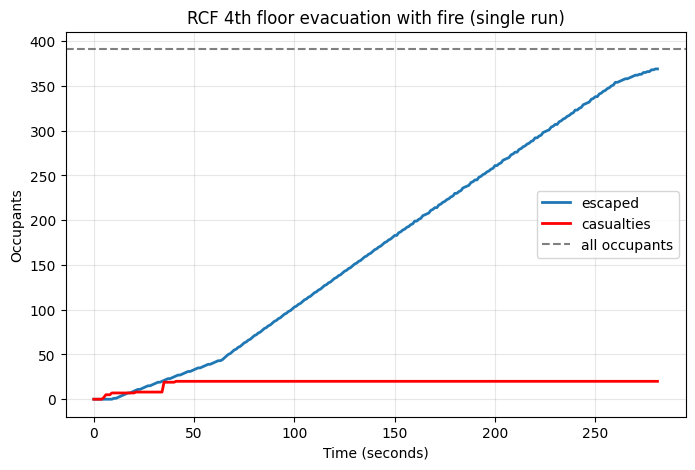

In [7]:
# ============================================================
# V3 CELL 7: one full run. Termination is now escaped + casualties
# == total (everyone is RESOLVED one way or the other), with a step
# cap in case agents get cut off and survive in a pocket.
# ============================================================
model = RCFFireModel(seed=42)
max_steps = 2000
while (model.escaped_count + model.casualty_count) < model.total_occupants \
        and model.step_num < max_steps:
    model.step()

print(f"Fire origin: {model.fire_origin} "
      f"({'RCF 400' if model.fire_origin in spawn400 else 'RCF 401'})")
print(f"Escaped:    {model.escaped_count} / {model.total_occupants}")
print(f"Casualties: {model.casualty_count}")
unresolved = model.total_occupants - model.escaped_count - model.casualty_count
print(f"Unresolved at step cap (cut off, alive): {unresolved}")
print(f"Run length: {model.step_num} sec ({model.step_num/60:.1f} min)")
s2, s3 = model.door_escape_count['stair2'], model.door_escape_count['stair3']
if s2 + s3 > 0:
    print(f"Stair split of escapees: {s2} Stair 2 / {s3} Stair 3")

df = model.datacollector.get_model_vars_dataframe()
plt.figure(figsize=(8, 5))
plt.plot(df.index, df["Escaped"], linewidth=2, label="escaped")
plt.plot(df.index, df["Casualties"], linewidth=2, color="red", label="casualties")
plt.axhline(model.total_occupants, color="gray", linestyle="--", label="all occupants")
plt.xlabel("Time (seconds)"); plt.ylabel("Occupants")
plt.title("RCF 4th floor evacuation with fire (single run)")
plt.legend(); plt.grid(alpha=0.3); plt.show()

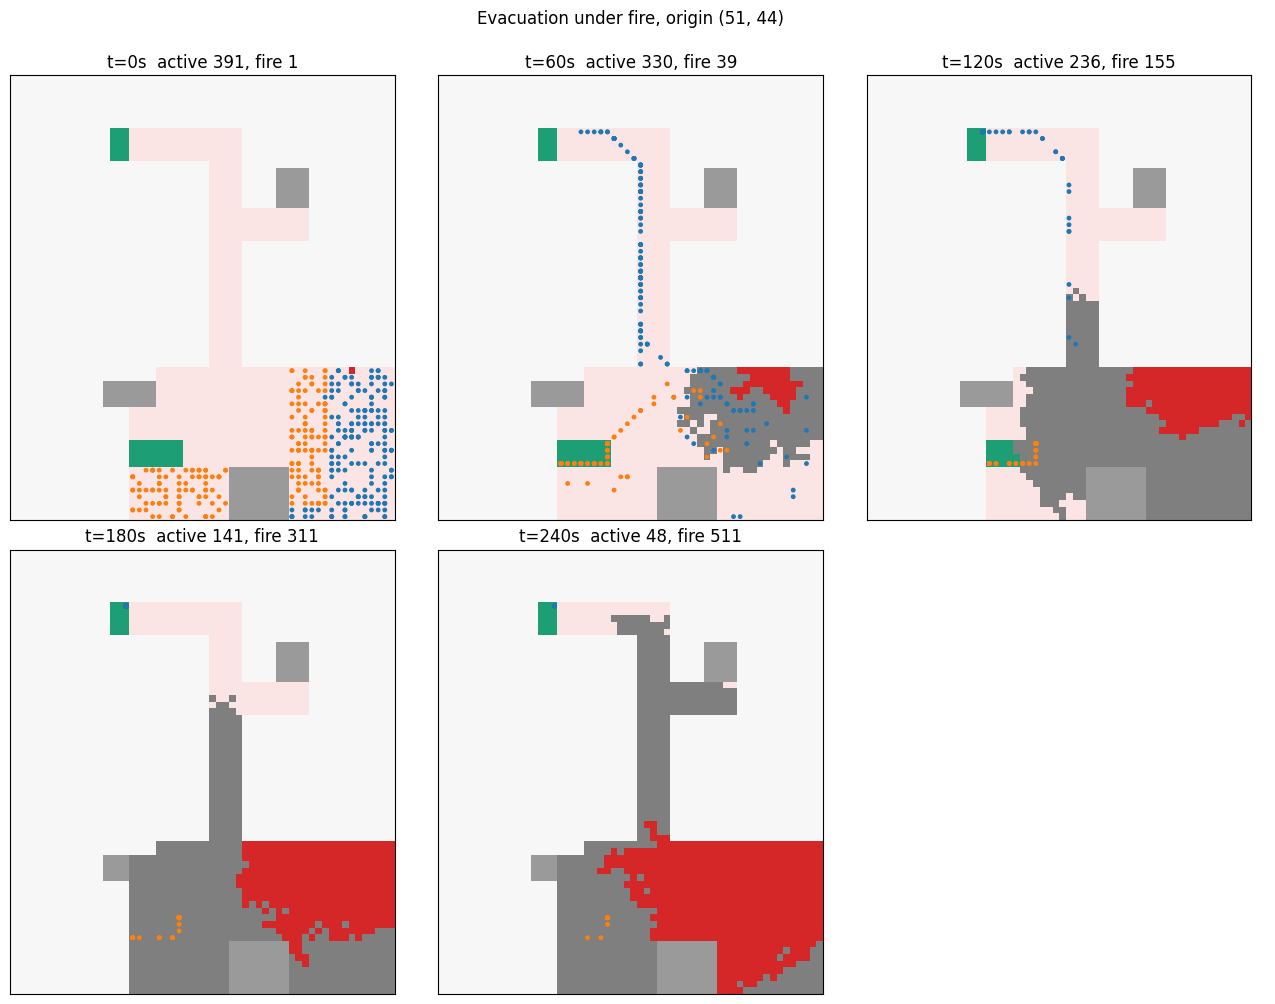

In [8]:
# ============================================================
# V3 CELL 8: visual validation. Re-runs a seeded model, snapshotting
# floor + smoke + fire + agents at intervals. This replaces the
# isolation step we folded in: you SEE rerouting and the hazard
# interacting before trusting the statistics.
# ============================================================
snap_model = RCFFireModel(seed=42)
snapshot_times = [0, 60, 120, 180, 240, 300]
frames = {}

def capture(m):
    agents = [(a.pos, a.target_stair) for a in m.agents
              if a.state == "moving" and a.pos is not None]
    return (set(m.burning), set(m.smoky), agents)

frames[0] = capture(snap_model)
while snap_model.step_num < max(snapshot_times) and \
      (snap_model.escaped_count + snap_model.casualty_count) < snap_model.total_occupants:
    snap_model.step()
    if snap_model.step_num in snapshot_times:
        frames[snap_model.step_num] = capture(snap_model)

fig, axes = plt.subplots(2, 3, figsize=(13, 10))
for ax, t in zip(axes.flat, snapshot_times):
    if t not in frames:                      # run ended early
        ax.axis('off'); continue
    b, s, agents = frames[t]
    arr = np.zeros((HEIGHT, WIDTH), dtype=int)
    for (c, r) in walkable: arr[r][c] = 1
    for (c, r) in exits:    arr[r][c] = 2
    for (c, r) in dead:     arr[r][c] = 5
    for (c, r) in s:        arr[r][c] = 6
    for (c, r) in b:        arr[r][c] = 7
    ax.imshow(arr, cmap=cmap, vmin=0, vmax=7, origin='upper',
              interpolation='nearest')
    if agents:
        xs = [p[0] for p, st in agents]; ys = [p[1] for p, st in agents]
        cs = ['tab:blue' if st == 'stair2' else 'tab:orange' for p, st in agents]
        ax.scatter(xs, ys, s=6, c=cs, zorder=5)
    ax.set_title(f"t={t}s  active {len(agents)}, fire {len(b)}")
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"Evacuation under fire, origin {snap_model.fire_origin}", y=1.0)
plt.tight_layout(); plt.show()

 seed origin_room  origin_dist_s3  escaped  casualties  unresolved  time
    0      RCF400              30      390           1           0   306
    1      RCF401               5      287         104           0   309
    2      RCF400              30      386           5           0   300
    3      RCF400              17      347          44           0   287
    4      RCF400              17      386           5           0   305
    5      RCF400              25      385           6           0   296
    6      RCF400              29      391           0           0   307
    7      RCF400              24      390           1           0   303
    8      RCF401               7      301          90           0   306
    9      RCF400              22      316          75           0   241
   10      RCF400              24      337          54           0   279
   11      RCF400              21      391           0           0   307
   12      RCF400              22      377         

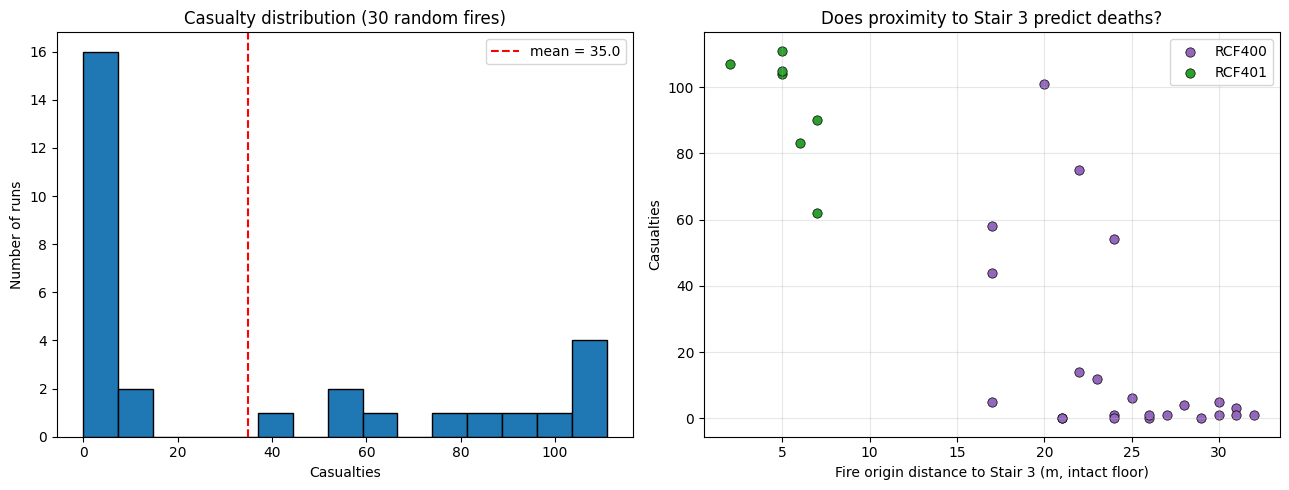

In [9]:
# ============================================================
# V3 CELL 9: Monte Carlo over random assembly-room fire origins.
# Each seed varies the origin AND occupant randomness, so the
# distribution answers: "across credible assembly-room fires, what
# range of outcomes does this floor produce?"
#
# NEW: records each run's origin DISTANCE TO STAIR 3 (the southwest
# stair, adjacent to RCF 401). Hypothesis from the bimodal casualty
# histogram: outcomes are governed by whether the fire compromises
# Stair 3's entry -- proximity should predict casualties better than
# which room the fire starts in.
# ============================================================
n_runs = 30
results = []

# Precompute a distance field to Stair 3 on the intact floor, once,
# just for measuring origin proximity (not used by the runs).
_s3_cells = {cell for cell in exits if cell[1] >= 30}
_dist_s3_intact = compute_distance_field(walkable, _s3_cells)

for seed in range(n_runs):
    m = RCFFireModel(seed=seed)
    while (m.escaped_count + m.casualty_count) < m.total_occupants and m.step_num < 2000:
        m.step()
    results.append({
        "seed": seed,
        "origin_room": "RCF400" if m.fire_origin in spawn400 else "RCF401",
        "origin_dist_s3": _dist_s3_intact.get(m.fire_origin, -1),
        "escaped": m.escaped_count,
        "casualties": m.casualty_count,
        "unresolved": m.total_occupants - m.escaped_count - m.casualty_count,
        "time": m.step_num,
    })

import pandas as pd
res = pd.DataFrame(results)
print(res.to_string(index=False))
print()
print(f"Mean casualties: {res['casualties'].mean():.1f} "
      f"(min {res['casualties'].min()}, max {res['casualties'].max()})")
print(f"Mean escaped:    {res['escaped'].mean():.1f} / {m.total_occupants}")
print(f"Mean run time:   {res['time'].mean()/60:.2f} min")
print()
print("By origin room:")
print(res.groupby("origin_room")[["casualties", "escaped", "time"]].mean().round(1))
print()
# Correlation between origin proximity to Stair 3 and casualties.
# Expect NEGATIVE: smaller distance (closer to the stair) -> more deaths.
corr = res["origin_dist_s3"].corr(res["casualties"])
print(f"Correlation (origin distance to Stair 3 vs casualties): {corr:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.hist(res["casualties"], bins=15, edgecolor="black")
ax1.axvline(res["casualties"].mean(), color="red", linestyle="--",
            label=f"mean = {res['casualties'].mean():.1f}")
ax1.set_xlabel("Casualties"); ax1.set_ylabel("Number of runs")
ax1.set_title(f"Casualty distribution ({n_runs} random fires)")
ax1.legend()

# The money plot: casualties vs origin distance to Stair 3, colored by room.
for room, color in [("RCF400", "tab:purple"), ("RCF401", "tab:green")]:
    sub = res[res["origin_room"] == room]
    ax2.scatter(sub["origin_dist_s3"], sub["casualties"],
                c=color, label=room, s=45, edgecolor="black", linewidth=0.5)
ax2.set_xlabel("Fire origin distance to Stair 3 (m, intact floor)")
ax2.set_ylabel("Casualties")
ax2.set_title("Does proximity to Stair 3 predict deaths?")
ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
from mesa.visualization import SolaraViz, make_space_component, make_plot_component

# ============================================================
# V3 CELL 10: live SolaraViz dashboard with fire + smoke.
#
# DESIGN: SolaraViz draws AGENTS, not arbitrary cell sets, so fire and
# smoke are mirrored as inert "marker" agents -- no-op step(), placed on
# cells as they ignite, never removed (hazards only grow). This reuses
# the exact portrayal API proven in v2 rather than new API surface.
#
# RCFFireModel (Cells 4-9) is NOT modified: a subclass adds the marker
# syncing, so the validated simulation stays frozen.
# ============================================================

class HazardMarker(mesa.Agent):
    """Inert visual marker for one burning or smoky cell."""
    def __init__(self, model, kind):
        super().__init__(model)
        self.kind = kind          # "fire" or "smoke"
        # state="hazard" makes every existing state check in the model
        # (_kill_agents_in_fire, _reassign_cut_off) skip markers safely.
        self.state = "hazard"

    def step(self):
        pass                      # markers never act


class RCFFireVizModel(RCFFireModel):
    """RCFFireModel + hazard markers kept in sync for the dashboard."""
    def __init__(self, n_400=304, n_401=87, seed=None):
        super().__init__(n_400=n_400, n_401=n_401, seed=seed)
        # Track which cells already have a marker so each cell gets one.
        self._marked_fire = set()
        self._marked_smoke = set()
        self._sync_markers()      # mark the origin before the first step

    def _sync_markers(self):
        """Place a marker on every newly smoky / newly burning cell."""
        for cell in self.smoky - self._marked_smoke:
            m = HazardMarker(self, "smoke")
            self.grid.place_agent(m, cell)
            self._marked_smoke.add(cell)
        for cell in self.burning - self._marked_fire:
            m = HazardMarker(self, "fire")
            self.grid.place_agent(m, cell)
            self._marked_fire.add(cell)

    def step(self):
        super().step()            # full validated v3 step, untouched
        self._sync_markers()      # then mirror the grown hazards


# ----------------------------------------------------------------------
# Portrayal: three layers by zorder.
#   smoke = gray squares underneath (zorder 0)
#   fire  = red squares above smoke (zorder 1)
#   occupants on top (zorder 2), colored by assigned stair, faded
#   while still in pre-movement -- same conventions as v2.
# Escaped occupants and casualties are off the grid, so never drawn.
# ----------------------------------------------------------------------
def agent_portrayal(agent):
    kind = getattr(agent, "kind", None)
    if kind == "smoke":
        return {"color": "gray", "marker": "s", "size": 28,
                "alpha": 0.35, "zorder": 0}
    if kind == "fire":
        return {"color": "red", "marker": "s", "size": 28,
                "alpha": 0.9, "zorder": 1}
    # Occupant.
    color = "tab:blue" if agent.target_stair == "stair2" else "tab:orange"
    still_reacting = agent.steps_waited < agent.reaction_delay
    return {"color": color, "size": 14,
            "alpha": 0.25 if still_reacting else 1.0, "zorder": 2}

def post_process(ax):
    ax.set_xlim(0, WIDTH)
    ax.set_ylim(0, HEIGHT)
    ax.invert_yaxis()             # north up, as v2
    ax.set_aspect("equal")
    ax.set_title("RCF 4th Floor under fire — gray smoke, red fire")

model_params = {
    "n_400": {"type": "SliderInt", "value": 304, "min": 50, "max": 400,
              "step": 10, "label": "RCF 400 occupants (large assembly)"},
    "n_401": {"type": "SliderInt", "value": 87, "min": 20, "max": 150,
              "step": 10, "label": "RCF 401 occupants (small assembly)"},
}

viz_model = RCFFireVizModel(n_400=304, n_401=87)
print(f"Viz model ready. Fire origin: {viz_model.fire_origin} "
      f"({'RCF 400' if viz_model.fire_origin in spawn400 else 'RCF 401'})")

page = SolaraViz(
    viz_model,
    components=[
        make_space_component(
            agent_portrayal,
            post_process=post_process,
            backend="matplotlib",
        ),
        make_plot_component(["Escaped", "Casualties"]),
    ],
    model_params=model_params,
    name="Fire Egress Simulation v3 — RCF 4th Floor with Fire",
)
page

Viz model ready. Fire origin: (45, 45) (RCF 400)


c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\visualization\mpl_space_drawing.py:465: FutureWarning: Returning a dict from agent_portrayal is deprecated and will be removed in Mesa 4.0. Please return an AgentPortrayalStyle instance instead. For more information, refer to the migration guide: https://mesa.readthedocs.io/latest/migration_guide.html#defining-portrayal-components
  arguments = collect_agent_data(space, agent_portrayal, default_size=s_default)


Cannot show ipywidgets in text

In [11]:
import matplotlib.animation as animation

# ============================================================
# V3 CELL 11: GIF EXPORT -- renders one full evacuation-under-fire
# run to an animated GIF (same technique as the v2 exporter: drive
# the model ourselves, draw each step, save with Pillow).
#
# SEED CHOICE: seed 1 is an RCF 401 fire adjacent to the south stair
# -- the floor's failure mode. The GIF should show the stair being
# lost and the orange crowd rerouting north. Change GIF_SEED to
# export a different scenario.
# ============================================================

GIF_SEED = 1

# ---- 1. Run to completion, capturing state every step ----
gif_model = RCFFireModel(seed=GIF_SEED)
frames_data = []

def capture(m):
    agents = [(a.pos, a.target_stair) for a in m.agents
              if a.state == "moving" and a.pos is not None]
    return {"burning": set(m.burning), "smoky": set(m.smoky),
            "agents": agents, "escaped": m.escaped_count,
            "casualties": m.casualty_count, "step": m.step_num}

frames_data.append(capture(gif_model))
while (gif_model.escaped_count + gif_model.casualty_count) < gif_model.total_occupants \
        and gif_model.step_num < 2000:
    gif_model.step()
    frames_data.append(capture(gif_model))

total_steps = len(frames_data)
print(f"Run captured: {total_steps} steps, "
      f"{gif_model.escaped_count} escaped, {gif_model.casualty_count} casualties, "
      f"origin {gif_model.fire_origin} "
      f"({'RCF 400' if gif_model.fire_origin in spawn400 else 'RCF 401'})")

# ---- 2. Subsample to a target GIF length ----
TARGET_SECONDS = 20.0
FPS = 15
stride = max(1, total_steps // int(TARGET_SECONDS * FPS))
frames_to_draw = frames_data[::stride]
if frames_to_draw[-1] is not frames_data[-1]:
    frames_to_draw.append(frames_data[-1])   # always end on the final state
print(f"Drawing {len(frames_to_draw)} frames (every {stride} steps) "
      f"-> ~{len(frames_to_draw)/FPS:.1f}s GIF")

# ---- 3. Static floor base array, built once ----
base_arr = np.zeros((HEIGHT, WIDTH), dtype=int)
for (c, r) in walkable: base_arr[r][c] = 1
for (c, r) in exits:    base_arr[r][c] = 2
for (c, r) in dead:     base_arr[r][c] = 5

fig, ax = plt.subplots(figsize=(6, 7))
# cmap (8 categories incl. smoke=6, fire=7) is defined in Cell 4.
im = ax.imshow(base_arr, cmap=cmap, vmin=0, vmax=7, origin='upper',
               interpolation='nearest')
scat = ax.scatter([], [], s=10, zorder=5)
ax.set_xticks([]); ax.set_yticks([])

# Stair labels so any viewer can read the geometry (south stair is the
# one the fire threatens in this scenario).
ax.text(16, 6, "Stair 2 (NW)", color="#1d9e75", fontsize=8, fontweight="bold")
ax.text(14, 53, "Stair 3 (S)", color="#1d9e75", fontsize=8, fontweight="bold")

# ---- 4. Per-frame update ----
def update(i):
    d = frames_to_draw[i]
    arr = base_arr.copy()
    for (c, r) in d["smoky"]:   arr[r][c] = 6
    for (c, r) in d["burning"]: arr[r][c] = 7
    im.set_data(arr)
    if d["agents"]:
        offsets = np.array([p for p, st in d["agents"]], dtype=float)
        cols = ['tab:blue' if st == 'stair2' else 'tab:orange'
                for p, st in d["agents"]]
    else:
        offsets = np.empty((0, 2))
        cols = []
    scat.set_offsets(offsets)
    scat.set_color(cols)
    mins, secs = divmod(int(d["step"]), 60)
    ax.set_title(f"RCF 4th floor fire  |  t = {mins}:{secs:02d}  |  "
                 f"escaped {d['escaped']}  casualties {d['casualties']}")
    return im, scat

anim = animation.FuncAnimation(fig, update, frames=len(frames_to_draw),
                               interval=1000 / FPS, blit=False)
out_path = "rcf_v3_fire_evacuation.gif"
anim.save(out_path, writer=animation.PillowWriter(fps=FPS))
plt.close(fig)
print(f"Saved {out_path}")

c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\mesa_logging.py:112: FutureWarning: The use of the `seed` keyword argument is deprecated, use `rng` instead. No functional changes.
  res = func(*args, **kwargs)


Run captured: 310 steps, 287 escaped, 104 casualties, origin (26, 63) (RCF 401)
Drawing 310 frames (every 1 steps) -> ~20.7s GIF


c:\Users\Nathan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\mesa\visualization\mpl_space_drawing.py:465: FutureWarning: Returning a dict from agent_portrayal is deprecated and will be removed in Mesa 4.0. Please return an AgentPortrayalStyle instance instead. For more information, refer to the migration guide: https://mesa.readthedocs.io/latest/migration_guide.html#defining-portrayal-components
  arguments = collect_agent_data(space, agent_portrayal, default_size=s_default)


Saved rcf_v3_fire_evacuation.gif
